In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [15]:
df1 = pd.read_csv("LA_AQS_2023.csv")
df2 = pd.read_csv("ManuaLoa_CO2.csv")

In [16]:
df1_O3 = df1[df1["Parameter Name"] == "Ozone"]
df1_NO2 = df1[df1["Parameter Name"] == "Nitrogen dioxide (NO2)"]

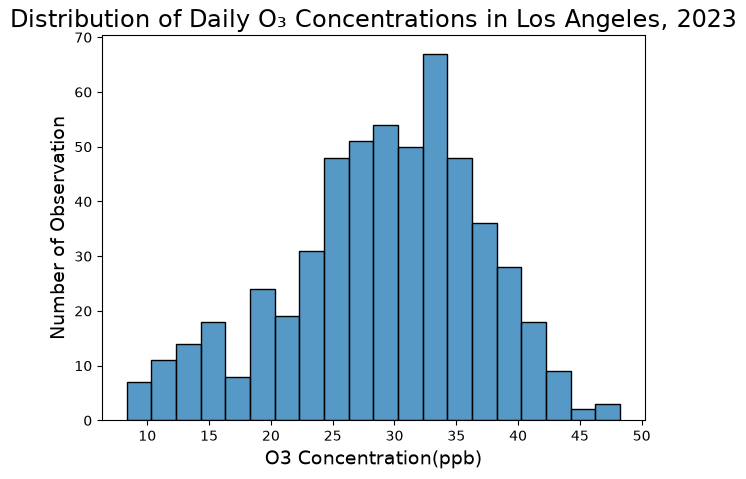

In [34]:
df1_O3["O3_ppb"] = df1_O3["Arithmetic Mean"] * 1000
plt.figure(figsize=(7, 5))
sb.histplot(
    data=df1_O3,
    x="O3_ppb",
    bins=20
)
plt.xlabel("O3 Concentration(ppb)", fontsize=14)
plt.ylabel("Number of Observation", fontsize=14)
plt.title("Distribution of Daily O₃ Concentrations in Los Angeles, 2023", fontsize=17)
plt.show()

This histogram shows that most of the time the O3 concentration is around 20 to 40, with few exceptions above or lower.

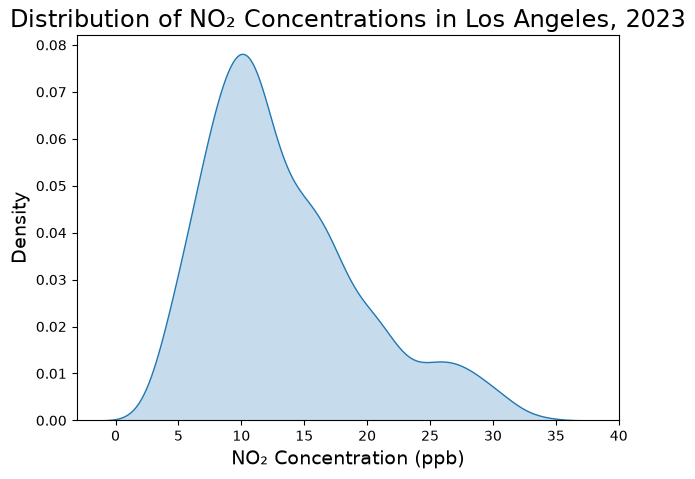

In [33]:
plt.figure(figsize=(7, 5))
sb.kdeplot(
    data=df1_NO2,
    x="Arithmetic Mean",
    fill=True
)

plt.xlabel("NO₂ Concentration (ppb)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Distribution of NO₂ Concentrations in Los Angeles, 2023", fontsize=17)
plt.show()

This density plot shows that the NO2 concentration are usualy between 0 to 25 with few exceptions of higher value

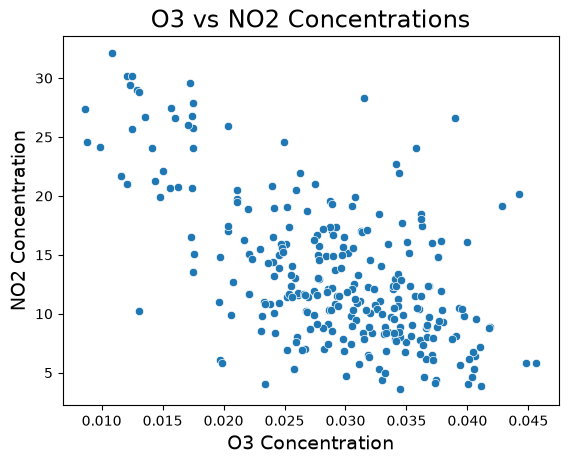

In [41]:
O3 = df1_O3.groupby("Date (Local)", as_index=False)["Arithmetic Mean"].mean()
NO2 = df1_NO2.groupby("Date (Local)", as_index=False)["Arithmetic Mean"].mean()

O3.columns = ["date", "O3"]
NO2.columns = ["date", "NO2"]

pair = O3.merge(NO2, on="date")

sb.scatterplot(data=pair, x="O3", y="NO2")
plt.xlabel("O3 Concentration", fontsize=14)
plt.ylabel("NO2 Concentration", fontsize=14)
plt.title("O3 vs NO2 Concentrations", fontsize=17)
plt.show()

There is the trend that the higher NO2 concentration is the lower O3 concentration is. 

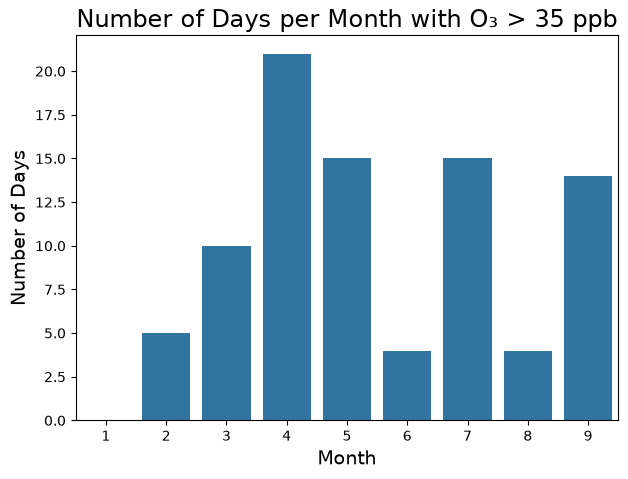

In [47]:
df1_O3["Date (Local)"] = pd.to_datetime(df1_O3["Date (Local)"])
O3_35 = df1_O3[df1_O3["O3_ppb"] > 35]

O3_35["month"] = pd.to_datetime(O3_35["Date (Local)"]).dt.month

monthly = O3_35.drop_duplicates("Date (Local)").groupby("month").size().reindex(range(1, 10), fill_value=0)

plt.figure(figsize=(7, 5))

sb.barplot(
    x=monthly.index,
    y=monthly.values
)

plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Days", fontsize=14)
plt.title("Number of Days per Month with O₃ > 35 ppb", fontsize=17)

plt.show()

It shows that except for Jan all month have days with 35ppb or larger concertration while april have the most days.

In [52]:
df2.columns

Index(['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays',
       'sdev', 'unc'],
      dtype='str')

In [51]:
df2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


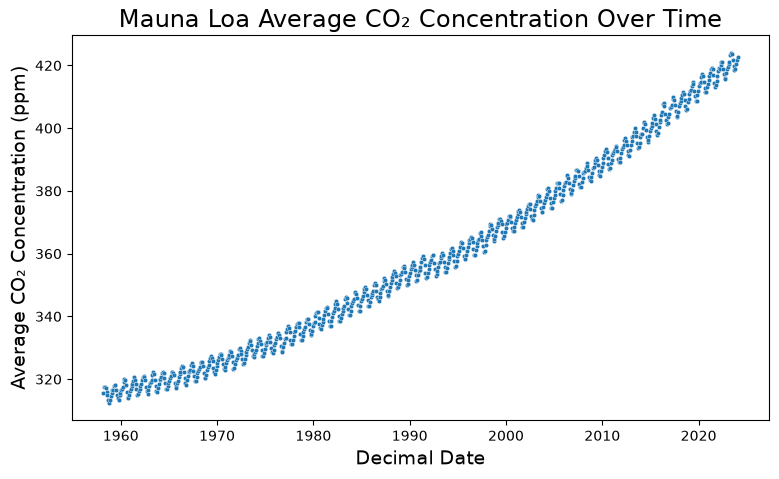

In [60]:
plt.figure(figsize=(9, 5))

sb.scatterplot(
    data=df2,
    x="decimal date",
    y="average",
    s=10
)

plt.xlabel("Decimal Date", fontsize=14)
plt.ylabel("Average CO2 Concentration (ppm)", fontsize=14)
plt.title("Mauna Loa Average CO2 Concentration Over Time", fontsize=17)
plt.show()

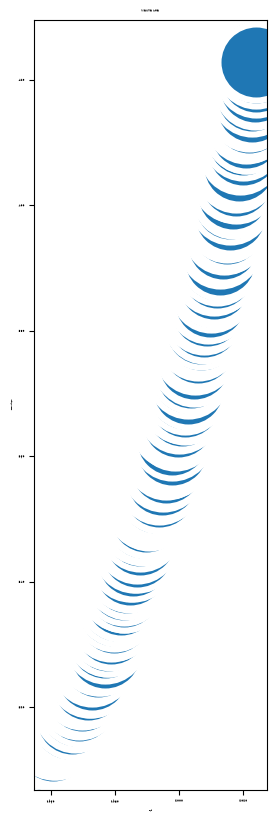

In [67]:
plt.figure(figsize=(3, 10))

sb.scatterplot(
    data=df2,
    x="decimal date",
    y="average",
    s=3000
)

plt.xlabel("Date", fontsize=1)
plt.ylabel("CO₂ Concentration", fontsize=1)
plt.yticks(fontsize=2)
plt.xticks(fontsize=2)
plt.title("Mauna Loa ", fontsize=2)
plt.show()